# LBG Ring-Intercept: MCTS Guard vs LQR Bandit

End-to-end demo for `orbital-game` after the protocol unification:

- One `Policy` protocol; both sides plug in the same way.
- `MCTSPolicy` is a JAX-native classic UCT search backed by `mctx`.
- `LQRBanditPolicy` is a closed-form receding-horizon LQR + per-axis clip.
- Scenario: 1 guard at ~200 m around the lady (RTN origin), 4 bandits
  on a 2:1 natural-motion ring at ~2 km, cold-gas thrusters (Moog 58E143,
  3.6 N, GN2, Isp 65 s, 3 kg propellant tank).

This notebook focuses on **showing how the policies compose end-to-end**.
The CPU/MPS speedup story for `MCTSPolicy` is in `mcts_cpu_vs_mps.ipynb`.


In [1]:
# This is a CPU end-to-end demo. Pin CPU as the default device BEFORE
# importing JAX so that on Apple Silicon (where `jax-mps` may auto-register
# the MPS backend) we don't accidentally dispatch the float64 reference
# orbit arrays to MLX, which only supports float32.
import os
os.environ['JAX_DEFAULT_DEVICE'] = 'cpu'

# Make repo root importable regardless of cwd.
import sys
from pathlib import Path
_here = Path.cwd()
if (_here / 'src' / 'orbital_game').is_dir():
    _repo_root = _here
elif (_here.parent / 'src' / 'orbital_game').is_dir():
    _repo_root = _here.parent
else:
    raise RuntimeError(f'Could not locate orbital-game repo root from cwd={_here}')
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

%load_ext autoreload
%autoreload 2

import time
import dataclasses

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from orbital_game import OrbitalGameEnv, Side
from orbital_game.adapters.pomdp import POMDPAdapter
from orbital_game.policies.mcts import MCTSPolicy
from orbital_game.policies.uniform_random import UniformRandomDiscretePolicy

from examples.lbg_ring_intercept import (
    build_scenario, RingInterceptParams,
    COLD_GAS_GUARD, COLD_GAS_BANDIT, PROPELLANT_KG,
)
from examples.policies.lqr_bandit import LQRBanditPolicy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Build the scenario

In [2]:
params = RingInterceptParams(
    n_bandits=4,
    ring_radius_m=2000.0,
    guard_ring_radius_m=200.0,
    breach_radius_m=5.0,
    catch_radius_m=50.0,
    dt=10.0,
    max_horizon_s=2000.0,
    seed=0,
)
cfg = build_scenario(params)
env = OrbitalGameEnv(cfg)
adapter = POMDPAdapter(env)

print('n_guards =', cfg.n_guards, '| n_bandits =', cfg.n_bandits)
print('truth_dynamics =', cfg.truth_dynamics)
print('mean_motion =', env.mean_motion, 'rad/s   (period:',
      f'{2*np.pi/env.mean_motion/60:.1f} min)')
print('flat state dim =', adapter.states_dim)
print('reward_fn =', type(env.reward_fn).__name__)
print('termination_fn =', type(env.termination_fn).__name__)
print('guard cmd dv shape:', env.guard_command_cls.zeros(cfg.n_guards).dv.shape,
      '  (RT: 2-D, RTN: 3-D)')

WET = COLD_GAS_GUARD.dry_mass_kg + PROPELLANT_KG
DV_MAX = COLD_GAS_GUARD.max_thrust_n * cfg.dt / WET
print(f'wet mass = {WET} kg')
print(f'max Δv per step = {DV_MAX:.2f} m/s')
print(f'total Δv budget ~= {COLD_GAS_BANDIT.isp_s * 9.80665 * np.log(WET / COLD_GAS_BANDIT.dry_mass_kg):.0f} m/s')


n_guards = 1 | n_bandits = 4
truth_dynamics = hcw_rt
mean_motion = 0.0010977442493458165 rad/s   (period: 95.4 min)
flat state dim = 27
reward_fn = LbgZeroSumReward
termination_fn = LbgEventTermination
guard cmd dv shape: (1, 2)   (RT: 2-D, RTN: 3-D)
wet mass = 15.0 kg
max Δv per step = 2.40 m/s
total Δv budget ~= 142 m/s


## 2. Visualize initial conditions

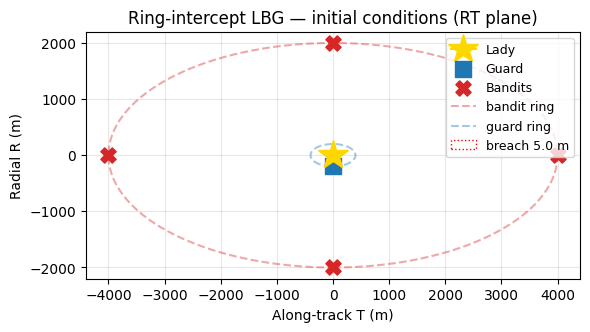

In [3]:
key0 = jax.random.PRNGKey(0)
state, _ = env.reset(key0)
gp = np.asarray(state.guards.rt[:, :2])
bp = np.asarray(state.bandits.rt[:, :2])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(0, 0, marker='*', color='gold', markersize=22, label='Lady', zorder=5)
ax.scatter(gp[:, 1], gp[:, 0], s=140, c='C0', marker='s', label='Guard', zorder=4)
ax.scatter(bp[:, 1], bp[:, 0], s=120, c='C3', marker='X', label='Bandits', zorder=4)
theta = np.linspace(0, 2 * np.pi, 200)
r_e = params.ring_radius_m
ax.plot(2 * r_e * np.sin(theta), -r_e * np.cos(theta), 'C3--', alpha=0.4, label='bandit ring')
g_e = params.guard_ring_radius_m
ax.plot(2 * g_e * np.sin(theta), -g_e * np.cos(theta), 'C0--', alpha=0.4, label='guard ring')
br = params.breach_radius_m
ax.add_patch(plt.Circle((0, 0), br, fill=False, color='red', linestyle=':', label=f'breach {br} m'))
ax.set_xlabel('Along-track T (m)')
ax.set_ylabel('Radial R (m)')
ax.set_title('Ring-intercept LBG — initial conditions (RT plane)')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Wire policies — MCTS guard vs LQR bandit

Both sides conform to the unified `Policy` protocol. The MCTS guard uses
`UniformRandomDiscretePolicy` as its **opponent model** inside the search
tree: this is the searcher's *belief about the opponent*, not a "scripted
opponent" baked into the planner. For sharper search, a user can wire any
fast Policy here (LQR, lead-intercept, learned prior).


In [4]:
# 9-direction RT-plane action grid (8 unit dirs at DV_MAX + no-op).
angles = np.linspace(0.0, 2.0 * np.pi, 8, endpoint=False)
grid_2d = DV_MAX * np.stack([np.cos(angles), np.sin(angles)], axis=-1)
action_grid = jnp.asarray(np.concatenate([grid_2d, np.zeros((1, 2))], axis=0), dtype=jnp.float32)
print('action grid shape:', action_grid.shape)

# Bandit-side LQR policy (closed-form, vmappable).
lqr = LQRBanditPolicy.from_env(env, horizon=8, control_cost=1e-3, dv_max=DV_MAX)
print(f'LQR bandit: gain shape={lqr.gain.shape}, dv_max={lqr.dv_max:.2f} m/s')

# MCTS guard. Default opponent model = uniform-random over the same grid.
opponent_model = UniformRandomDiscretePolicy(
    action_grid=action_grid,
    n_vehicles=cfg.n_bandits,
    command_cls=env.bandit_command_cls,
)
mcts = MCTSPolicy(
    env_model=adapter,
    side=Side.GUARD,
    action_grid=action_grid,
    opponent_model=opponent_model,
    opponent_action_grid=action_grid,
    num_simulations=32,
    n_vehicles=cfg.n_guards,
    command_cls=env.guard_command_cls,
)
print(f'MCTS guard: A={action_grid.shape[0]}, num_simulations={mcts.num_simulations}, '
      f'variant={mcts.variant}')


action grid shape: (9, 2)
LQR bandit: gain shape=(2, 4), dv_max=2.40 m/s
MCTS guard: A=9, num_simulations=32, variant=gumbel_muzero


## 4. Single trajectory — Python outer loop

`MCTSPolicy` satisfies the regular `Policy` protocol, so it could be wired
directly into `rollout` or `belief_rollout` if the upstream observation /
belief carried the flat state. For this demo we drive the env from a
manual Python loop calling `policy(None, adapter.pack(state), ...)` each
tick — direct, transparent, and matches what one would do for ad-hoc
research scripts.


In [5]:
from orbital_game.env.types import Actions, BySide
from orbital_game.observations.types import flatten_observations

def run_one_trajectory(env, adapter, guard_policy, bandit_policy, key, max_steps):
    state, _ = env.reset(jax.random.fold_in(key, 0))
    states = [state]
    rewards_g, rewards_b = [], []
    for step in range(max_steps):
        sub = jax.random.fold_in(key, step + 1)
        k_g, k_b, k_env = jax.random.split(sub, 3)
        s_flat = adapter.pack(state)
        g_cmd, _ = guard_policy(None, s_flat, k_g, state.t)
        # Bandit's obs is its own flat observation derived from current state.
        identity = Actions(sides=BySide(
            guard=env.guard_command_cls.zeros(cfg.n_guards),
            bandit=env.bandit_command_cls.zeros(cfg.n_bandits),
        ))
        bandit_obs_raw = env.bandit_observation_fn(
            state, identity, Side.BANDIT, env.config, k_b, state.t,
        )
        bandit_view = flatten_observations(bandit_obs_raw)
        b_cmd, _ = bandit_policy(None, bandit_view, k_b, state.t)
        actions = Actions(sides=BySide(guard=g_cmd, bandit=b_cmd))
        out = env.step(k_env, state, actions)
        state = out.state
        states.append(state)
        rewards_g.append(float(out.outputs.guard.reward))
        rewards_b.append(float(out.outputs.bandit.reward))
        if bool(out.episode_done):
            break
    return states, np.asarray(rewards_g), np.asarray(rewards_b)

t0 = time.perf_counter()
states_demo, rg, rb = run_one_trajectory(
    env, adapter, mcts, lqr,
    key=jax.random.PRNGKey(7),
    max_steps=int(cfg.max_horizon_s / cfg.dt),
)
dt = time.perf_counter() - t0
n_steps = len(rg)
print(f'Trajectory: {n_steps} steps in {dt:.2f}s ({dt/max(1,n_steps)*1000:.1f} ms/step avg)')
print(f'Guard cum reward:  {rg.sum():.1f}')
print(f'Bandit cum reward: {rb.sum():.1f}')
print(f'Final propellant — guard:   {float(states_demo[-1].guards.propellant_mass[0]):.3f} kg')
print(f'Final propellant — bandits: {np.asarray(states_demo[-1].bandits.propellant_mass)} kg')


Trajectory: 26 steps in 27.59s (1061.2 ms/step avg)
Guard cum reward:  -1033.0
Bandit cum reward: 981.2
Final propellant — guard:   1.704 kg
Final propellant — bandits: [2.27043128 1.82946295 2.27043128 1.82946295] kg


## 5. Trajectory plot

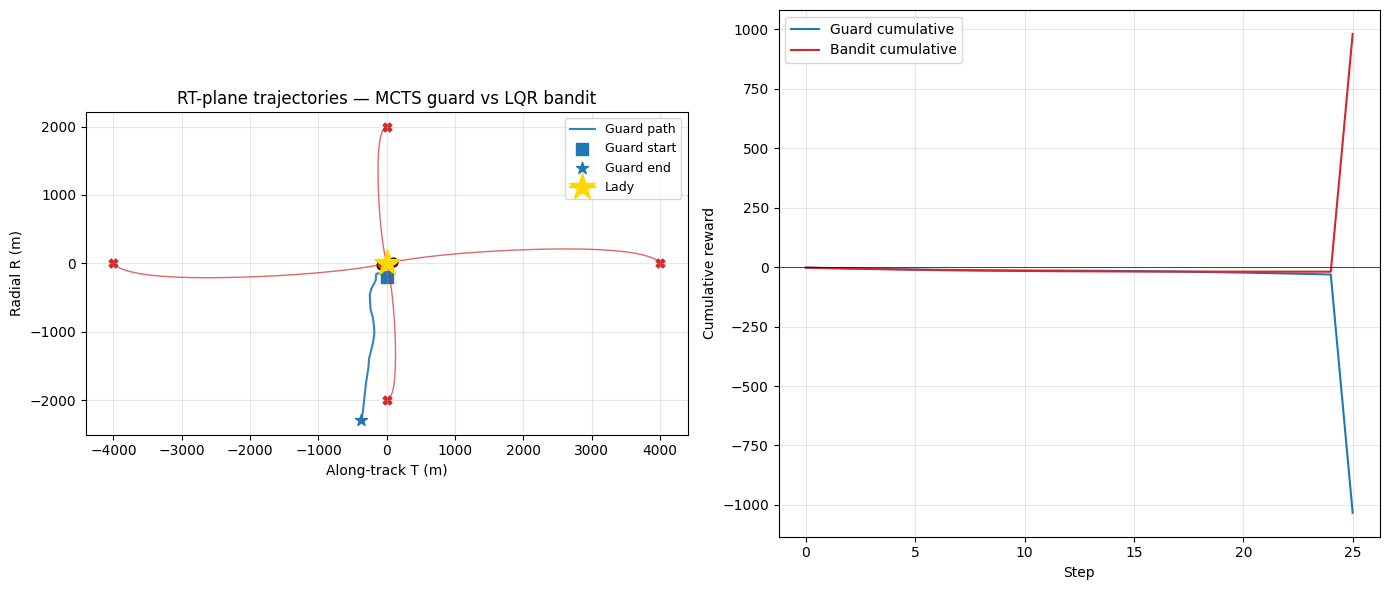

In [6]:
traj_g = np.stack([np.asarray(s.guards.rt[:, :2]) for s in states_demo])
traj_b = np.stack([np.asarray(s.bandits.rt[:, :2]) for s in states_demo])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for i in range(traj_b.shape[1]):
    ax.plot(traj_b[:, i, 1], traj_b[:, i, 0], 'C3-', alpha=0.7, lw=1.0)
    ax.scatter(traj_b[0, i, 1], traj_b[0, i, 0], s=40, c='C3', marker='X')
    ax.scatter(traj_b[-1, i, 1], traj_b[-1, i, 0], s=40, c='C3', marker='o', edgecolors='k')
ax.plot(traj_g[:, 0, 1], traj_g[:, 0, 0], 'C0-', alpha=0.9, lw=1.5, label='Guard path')
ax.scatter(traj_g[0, 0, 1], traj_g[0, 0, 0], s=80, c='C0', marker='s', label='Guard start')
ax.scatter(traj_g[-1, 0, 1], traj_g[-1, 0, 0], s=80, c='C0', marker='*', label='Guard end')
ax.plot(0, 0, marker='*', color='gold', markersize=20, zorder=10, label='Lady')
ax.add_patch(plt.Circle((0, 0), params.breach_radius_m, fill=False, color='red', linestyle=':'))
ax.set_xlabel('Along-track T (m)'); ax.set_ylabel('Radial R (m)')
ax.set_title('RT-plane trajectories — MCTS guard vs LQR bandit')
ax.set_aspect('equal'); ax.legend(loc='upper right', fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(np.cumsum(rg), 'C0-', label='Guard cumulative')
ax.plot(np.cumsum(rb), 'C3-', label='Bandit cumulative')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Step'); ax.set_ylabel('Cumulative reward')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 6. Compare guard policies over multiple trajectories

Drop `MCTSPolicy` and a baseline `UniformRandomDiscretePolicy` head-to-head
against the same LQR bandit. Each trajectory uses an independent random
seed; outcome is one of breach (bandit wins), catch (guard wins), or
neither within the horizon.


In [7]:
def evaluate(env, adapter, guard_policy, bandit_policy, n_traj, max_steps, base_seed=42):
    rewards = []
    breaches = catches = 0
    for j in range(n_traj):
        states, rg, rb = run_one_trajectory(
            env, adapter, guard_policy, bandit_policy,
            key=jax.random.PRNGKey(base_seed + j),
            max_steps=max_steps,
        )
        rewards.append(rg.sum())
        last_b = np.asarray(states[-1].bandits.rt[:, :2])
        last_g = np.asarray(states[-1].guards.rt[:, :2])
        d_lady = np.linalg.norm(last_b, axis=-1).min()
        d_gb = np.linalg.norm(last_g[:, None] - last_b, axis=-1).min()
        if d_lady < cfg.game.breach_distance_m:
            breaches += 1
        if d_gb < params.catch_radius_m:
            catches += 1
    return np.array(rewards), breaches, catches


N_TRAJ = 8
SHORT_MAX_STEPS = 60

guard_random = UniformRandomDiscretePolicy(
    action_grid=action_grid, n_vehicles=cfg.n_guards, command_cls=env.guard_command_cls,
)

print(f'\n=== Random guard ({N_TRAJ} trajectories) ===')
r_rand, br_rand, ca_rand = evaluate(env, adapter, guard_random, lqr, N_TRAJ, SHORT_MAX_STEPS)
print(f'  Outcomes: {br_rand} breaches, {ca_rand} catches | mean reward {r_rand.mean():.1f}')

print(f'\n=== MCTS guard ({N_TRAJ} trajectories, num_simulations={mcts.num_simulations}) ===')
r_mcts, br_mcts, ca_mcts = evaluate(env, adapter, mcts, lqr, N_TRAJ, SHORT_MAX_STEPS)
print(f'  Outcomes: {br_mcts} breaches, {ca_mcts} catches | mean reward {r_mcts.mean():.1f}')

print(f'\nMCTS reward improvement over random: {r_mcts.mean() - r_rand.mean():+.1f}')



=== Random guard (8 trajectories) ===
  Outcomes: 7 breaches, 1 catches | mean reward -772.6

=== MCTS guard (8 trajectories, num_simulations=32) ===
  Outcomes: 6 breaches, 2 catches | mean reward -524.1

MCTS reward improvement over random: +248.5


## 7. Notes

- `MCTSPolicy` is a regular `Policy` — slot it in for either side, with
  any opponent_model.
- The opponent model used inside the search is the **searcher's belief
  about the opponent**, distinct from the opponent's actual game-time
  policy. Both are first-class Policies.
- Wiring the same MCTS guard with a stronger opponent_model (e.g. an LQR
  policy whose obs slicing matches the search's per-pair view) typically
  sharpens the search; the cost is one extra Policy evaluation per node
  expansion.
- For `MCTSPolicy` + KF/EKF beliefs, write a small Belief whose `mean`
  field is the adapter's flat state vector, then drive via
  `belief_rollout`. See `docs/in-depth/mcts.md` for the recipe.
